In [1]:
import warnings
warnings.filterwarnings("ignore")

from pathlib import Path
import json
import pickle
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.metrics import mean_absolute_error, mean_squared_error

np.random.seed(42)
pd.set_option("display.max_columns", 40)
pd.set_option("display.float_format", lambda x: f"{x:,.2f}")

print("✅ Base libraries loaded")

✅ Base libraries loaded


In [2]:
# If needed:  python -m pip install xgboost
from xgboost import XGBRegressor

print("✅ XGBoost imported")

✅ XGBoost imported


In [3]:
FEATURES_PATH = None
for cand in [
    Path("../../datasets/processed/features.csv"),
    Path("../datasets/processed/features.csv"),
    Path("datasets/processed/features.csv"),
]:
    if cand.exists():
        FEATURES_PATH = cand.resolve()
        break

if FEATURES_PATH is None:
    raise FileNotFoundError("features.csv not found. Run 03_feature_engineering first.")

MODEL_DIR = Path("../../ml/models")
MODEL_DIR.mkdir(parents=True, exist_ok=True)
MODEL_PATH = MODEL_DIR / "xgboost_model.pkl"
METRICS_PATH = MODEL_DIR / "xgboost_metrics.json"

print(f"📂 Features: {FEATURES_PATH}")
print(f"📂 Model   : {MODEL_PATH}")

📂 Features: C:\Users\ASUS\OneDrive\Desktop\claude-test\smart-retail-intelligence-platform\datasets\processed\features.csv
📂 Model   : ..\..\ml\models\xgboost_model.pkl


In [4]:
feat = pd.read_csv(FEATURES_PATH, low_memory=False)
feat["ds"] = pd.to_datetime(feat["ds"])
feat = feat.sort_values("ds").reset_index(drop=True)

print(f"Rows : {len(feat):,}")
print(f"Range: {feat['ds'].min().date()} → {feat['ds'].max().date()}")
print("Split:", feat["split"].value_counts().to_dict())
feat.head(3)

Rows : 1,065
Range: 2021-01-31 → 2023-12-31
Split: {'train': 736, 'test': 165, 'val': 164}


,ds,split,y,y_revenue,y_quantity,y_profit,y_transactions,year,month,day,day_of_week,week_of_year,quarter,is_weekend,is_month_start,is_month_end,month_sin,month_cos,dow_sin,dow_cos,...,roll_max_14,roll_mean_30,roll_std_30,roll_min_30,roll_max_30,promo_share,festival_share,holiday_share,avg_discount,avg_stock,stockout_share,n_stores,n_products,is_promo_day,is_festival_day,is_holiday_day,high_discount_day,high_stockout_day,weekend_x_promo,festival_x_promo
0,2021-01-31,train,"9,310,912.43","9,310,912.43",1509,"1,993,427.54",272,2021,1,31,6,4,1,1,0,1,0.50,0.87,-0.78,0.62,...,"16,808,163.46","8,619,262.86","2,742,577.66","5,796,841.72","16,808,163.46",0.48,0.00,0.00,0.13,100.37,0.02,10,148,1,0,0,0,0,1,0
1,2021-02-01,train,"7,859,465.60","7,859,465.60",909,"1,770,156.16",273,2021,2,1,0,5,1,0,1,0,0.87,0.50,0.00,1.00,...,"16,808,163.46","8,652,505.49","2,744,788.49","5,796,841.72","16,808,163.46",0.52,0.00,0.00,0.14,101.59,0.00,10,144,1,0,0,0,0,0,0
2,2021-02-02,train,"6,899,503.98","6,899,503.98",842,"1,348,847.95",246,2021,2,2,1,5,1,0,0,0,0.87,0.50,0.78,0.62,...,"16,808,163.46","8,505,535.21","2,661,261.07","5,796,841.72","16,808,163.46",0.52,0.00,0.00,0.14,104.37,0.02,10,145,1,0,0,0,0,0,0


In [5]:
exclude = {
    "ds", "split", "y", "y_revenue", "y_quantity", "y_profit", "y_transactions",
    "season",  # use season_enc
}

feature_cols = [
    c for c in feat.columns
    if c not in exclude and pd.api.types.is_numeric_dtype(feat[c])
]

print(f"Using {len(feature_cols)} features:")
for c in feature_cols:
    print(f"  • {c}")

Using 47 features:
  • year
  • month
  • day
  • day_of_week
  • week_of_year
  • quarter
  • is_weekend
  • is_month_start
  • is_month_end
  • month_sin
  • month_cos
  • dow_sin
  • dow_cos
  • season_enc
  • lag_1
  • lag_7
  • lag_14
  • lag_30
  • lag_qty_1
  • lag_qty_7
  • roll_mean_7
  • roll_std_7
  • roll_min_7
  • roll_max_7
  • roll_mean_14
  • roll_std_14
  • roll_min_14
  • roll_max_14
  • roll_mean_30
  • roll_std_30
  • roll_min_30
  • roll_max_30
  • promo_share
  • festival_share
  • holiday_share
  • avg_discount
  • avg_stock
  • stockout_share
  • n_stores
  • n_products
  • is_promo_day
  • is_festival_day
  • is_holiday_day
  • high_discount_day
  • high_stockout_day
  • weekend_x_promo
  • festival_x_promo


In [6]:
def make_xy(df, cols):
    X = df[cols].copy()
    y = df["y"].astype(float).values
    X = X.fillna(X.median(numeric_only=True))
    return X, y

train = feat[feat["split"] == "train"].copy()
val   = feat[feat["split"] == "val"].copy()
test  = feat[feat["split"] == "test"].copy()

X_train, y_train = make_xy(train, feature_cols)
X_val, y_val     = make_xy(val, feature_cols)
X_test, y_test   = make_xy(test, feature_cols)

print(f"Train: {X_train.shape}")
print(f"Val  : {X_val.shape}")
print(f"Test : {X_test.shape}")

Train: (736, 47)
Val  : (164, 47)
Test : (165, 47)


In [7]:
def metrics_dict(y_true, y_pred, eps=1e-8):
    y_true = np.asarray(y_true, dtype=float)
    y_pred = np.asarray(y_pred, dtype=float)
    mae = mean_absolute_error(y_true, y_pred)
    rmse = float(np.sqrt(mean_squared_error(y_true, y_pred)))
    mape = float(np.mean(np.abs((y_true - y_pred) / np.clip(np.abs(y_true), eps, None))) * 100)
    return {"MAE": float(mae), "RMSE": rmse, "MAPE": mape, "n": int(len(y_true))}

def print_metrics(title, met):
    print("=" * 50)
    print(title)
    print("=" * 50)
    for split in ["train", "val", "test"]:
        if split in met:
            m = met[split]
            print(f"  {split:5s}  MAE={m['MAE']:,.0f}  RMSE={m['RMSE']:,.0f}  MAPE={m['MAPE']:.2f}%")

In [8]:
xgb_model = XGBRegressor(
    n_estimators=400,
    learning_rate=0.05,
    max_depth=6,
    min_child_weight=5,
    subsample=0.8,
    colsample_bytree=0.8,
    reg_lambda=1.0,
    objective="reg:squarederror",
    random_state=42,
    n_jobs=-1,
)

# Fit with early stopping on validation (if val exists)
fit_params = {}
if len(X_val) > 0:
    fit_params["eval_set"] = [(X_val, y_val)]
    fit_params["verbose"] = False
    # early_stopping_rounds works on recent xgboost
    try:
        xgb_model.set_params(early_stopping_rounds=30)
    except Exception:
        pass

xgb_model.fit(X_train, y_train, **fit_params)

xgb_metrics = {
    "model": "xgboost",
    "train": metrics_dict(y_train, xgb_model.predict(X_train)),
}
if len(X_val):
    xgb_metrics["val"] = metrics_dict(y_val, xgb_model.predict(X_val))
if len(X_test):
    xgb_metrics["test"] = metrics_dict(y_test, xgb_model.predict(X_test))

print_metrics("XGBOOST (base)", xgb_metrics)

XGBOOST (base)
  train  MAE=373,561  RMSE=526,738  MAPE=4.58%
  val    MAE=896,040  RMSE=1,329,357  MAPE=10.48%
  test   MAE=961,932  RMSE=1,314,513  MAPE=11.21%


In [9]:
# Small grid — intermediate level, not heavy search
param_grid = [
    {"max_depth": 4, "learning_rate": 0.05, "min_child_weight": 5},
    {"max_depth": 6, "learning_rate": 0.05, "min_child_weight": 5},
    {"max_depth": 8, "learning_rate": 0.03, "min_child_weight": 3},
    {"max_depth": 6, "learning_rate": 0.03, "min_child_weight": 5},
]

best = None
best_val_mae = np.inf
results = []

for i, params in enumerate(param_grid, 1):
    m = XGBRegressor(
        n_estimators=400,
        subsample=0.8,
        colsample_bytree=0.8,
        reg_lambda=1.0,
        objective="reg:squarederror",
        random_state=42,
        n_jobs=-1,
        **params,
    )
    try:
        m.set_params(early_stopping_rounds=30)
    except Exception:
        pass

    fp = {"verbose": False}
    if len(X_val):
        fp["eval_set"] = [(X_val, y_val)]

    m.fit(X_train, y_train, **fp)

    if len(X_val):
        val_mae = mean_absolute_error(y_val, m.predict(X_val))
    else:
        val_mae = mean_absolute_error(y_train, m.predict(X_train))

    results.append({**params, "val_MAE": val_mae})
    print(f"  [{i}/{len(param_grid)}] {params} → val_MAE={val_mae:,.0f}")

    if val_mae < best_val_mae:
        best_val_mae = val_mae
        best = m
        best_params = params

print("\nBest params:", best_params)
print(f"Best val MAE: {best_val_mae:,.0f}")

xgb_model = best  # use best model going forward

xgb_metrics = {
    "model": "xgboost",
    "best_params": best_params,
    "train": metrics_dict(y_train, xgb_model.predict(X_train)),
}
if len(X_val):
    xgb_metrics["val"] = metrics_dict(y_val, xgb_model.predict(X_val))
if len(X_test):
    xgb_metrics["test"] = metrics_dict(y_test, xgb_model.predict(X_test))

print_metrics("XGBOOST (tuned)", xgb_metrics)
display(pd.DataFrame(results).sort_values("val_MAE"))

  [1/4] {'max_depth': 4, 'learning_rate': 0.05, 'min_child_weight': 5} → val_MAE=876,356
  [2/4] {'max_depth': 6, 'learning_rate': 0.05, 'min_child_weight': 5} → val_MAE=896,040
  [3/4] {'max_depth': 8, 'learning_rate': 0.03, 'min_child_weight': 3} → val_MAE=914,323
  [4/4] {'max_depth': 6, 'learning_rate': 0.03, 'min_child_weight': 5} → val_MAE=889,472

Best params: {'max_depth': 4, 'learning_rate': 0.05, 'min_child_weight': 5}
Best val MAE: 876,356
XGBOOST (tuned)
  train  MAE=556,231  RMSE=714,724  MAPE=6.82%
  val    MAE=876,356  RMSE=1,290,358  MAPE=10.26%
  test   MAE=969,592  RMSE=1,298,913  MAPE=11.35%


,max_depth,learning_rate,min_child_weight,val_MAE
0,4,0.05,5,"876,355.61"
3,6,0.03,5,"889,472.17"
1,6,0.05,5,"896,040.02"
2,8,0.03,3,"914,322.67"


Top 15 features:


,feature,importance
6,is_weekend,0.30
3,day_of_week,0.30
34,holiday_share,0.12
33,festival_share,0.07
32,promo_share,0.03
11,dow_sin,0.02
1,month,0.01
4,week_of_year,0.01
39,n_products,0.01
35,avg_discount,0.01


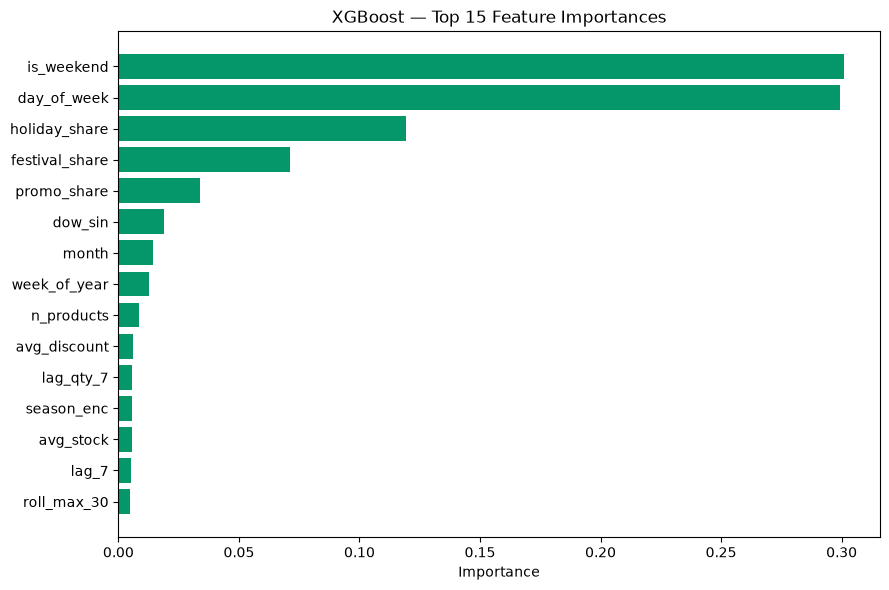

In [10]:
imp = pd.DataFrame({
    "feature": feature_cols,
    "importance": xgb_model.feature_importances_,
}).sort_values("importance", ascending=False)

print("Top 15 features:")
display(imp.head(15))

fig, ax = plt.subplots(figsize=(9, 6))
top = imp.head(15).iloc[::-1]
ax.barh(top["feature"], top["importance"], color="#059669")
ax.set_title("XGBoost — Top 15 Feature Importances")
ax.set_xlabel("Importance")
plt.tight_layout()
plt.show()

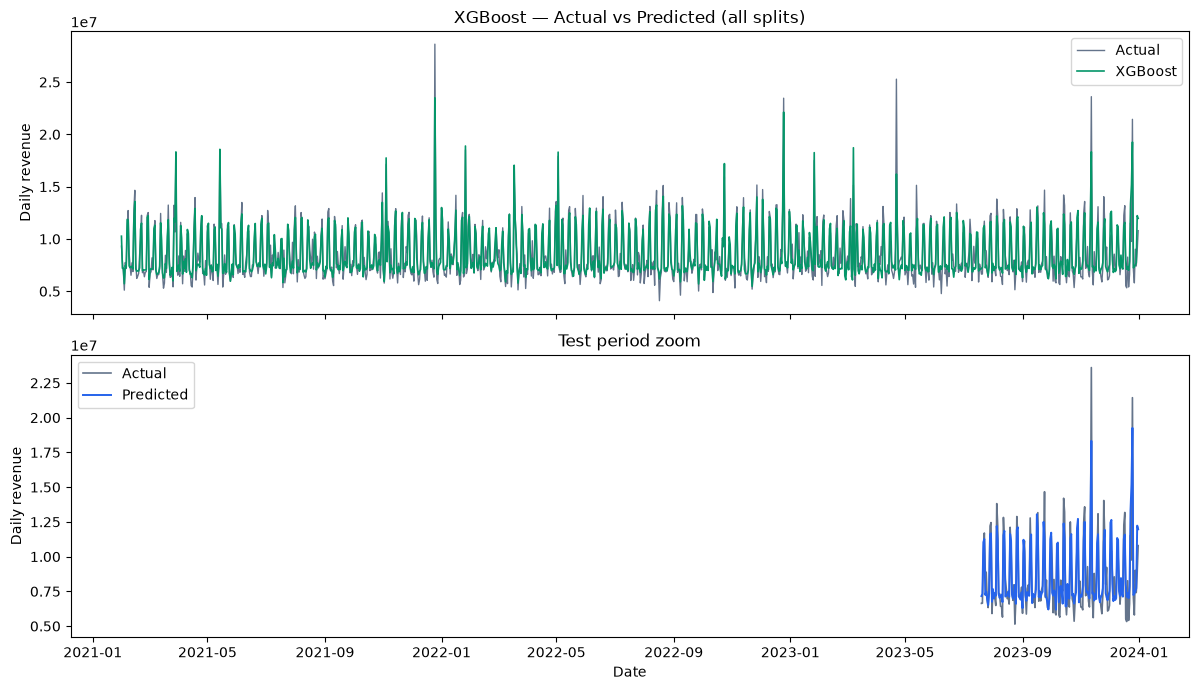

In [11]:
fig, axes = plt.subplots(2, 1, figsize=(12, 7), sharex=True)

# Full series style: train/val/test predictions concatenated by date
parts = []
for split_name, X_s, y_s, df_s in [
    ("train", X_train, y_train, train),
    ("val", X_val, y_val, val),
    ("test", X_test, y_test, test),
]:
    if len(df_s) == 0:
        continue
    pred = xgb_model.predict(X_s)
    parts.append(pd.DataFrame({
        "ds": df_s["ds"].values,
        "y": y_s,
        "yhat": pred,
        "split": split_name,
    }))

pred_all = pd.concat(parts, ignore_index=True).sort_values("ds")

axes[0].plot(pred_all["ds"], pred_all["y"], color="#64748b", linewidth=1, label="Actual")
axes[0].plot(pred_all["ds"], pred_all["yhat"], color="#059669", linewidth=1.2, label="XGBoost")
axes[0].set_title("XGBoost — Actual vs Predicted (all splits)")
axes[0].legend()
axes[0].set_ylabel("Daily revenue")

if len(test):
    te = pred_all[pred_all["split"] == "test"]
    axes[1].plot(te["ds"], te["y"], color="#64748b", linewidth=1.2, label="Actual")
    axes[1].plot(te["ds"], te["yhat"], color="#2563eb", linewidth=1.4, label="Predicted")
    axes[1].set_title("Test period zoom")
    axes[1].legend()
    axes[1].set_ylabel("Daily revenue")
    axes[1].set_xlabel("Date")
else:
    axes[1].set_visible(False)

plt.tight_layout()
plt.show()

In [12]:
# Final production model = train + val
train_val = feat[feat["split"].isin(["train", "val"])].copy()
X_tv, y_tv = make_xy(train_val, feature_cols)

final_params = {
    "n_estimators": 400,
    "subsample": 0.8,
    "colsample_bytree": 0.8,
    "reg_lambda": 1.0,
    "objective": "reg:squarederror",
    "random_state": 42,
    "n_jobs": -1,
}
# merge best tuned params if available
if "best_params" in xgb_metrics:
    final_params.update(xgb_metrics["best_params"])

final_xgb = XGBRegressor(**final_params)
final_xgb.fit(X_tv, y_tv)

bundle = {
    "model": final_xgb,
    "feature_cols": feature_cols,
    "model_type": "xgboost",
    "params": final_params,
    "metrics": xgb_metrics,
    "feature_importance": imp.to_dict(orient="records"),
    "target": "y",  # daily revenue
}

with open(MODEL_PATH, "wb") as f:
    pickle.dump(bundle, f)

with open(METRICS_PATH, "w") as f:
    json.dump(xgb_metrics, f, indent=2)

print(f"✅ Model   → {MODEL_PATH}")
print(f"✅ Metrics → {METRICS_PATH}")
print(f"   Size    : {MODEL_PATH.stat().st_size / 1024:.1f} KB")
print("\nNext → 06_model_comparison.ipynb")

✅ Model   → ..\..\ml\models\xgboost_model.pkl
✅ Metrics → ..\..\ml\models\xgboost_metrics.json
   Size    : 573.8 KB

Next → 06_model_comparison.ipynb


In [13]:
with open(MODEL_PATH, "rb") as f:
    loaded = pickle.load(f)

print("Type     :", loaded["model_type"])
print("Features :", len(loaded["feature_cols"]))
print("Params   :", loaded["params"])
if "val" in loaded["metrics"]:
    print("Val MAPE :", round(loaded["metrics"]["val"]["MAPE"], 2), "%")
if "test" in loaded["metrics"]:
    print("Test MAPE:", round(loaded["metrics"]["test"]["MAPE"], 2), "%")
print("✅ XGBoost pipeline OK")

Type     : xgboost
Features : 47
Params   : {'n_estimators': 400, 'subsample': 0.8, 'colsample_bytree': 0.8, 'reg_lambda': 1.0, 'objective': 'reg:squarederror', 'random_state': 42, 'n_jobs': -1, 'max_depth': 4, 'learning_rate': 0.05, 'min_child_weight': 5}
Val MAPE : 10.26 %
Test MAPE: 11.35 %
✅ XGBoost pipeline OK
